### **Modeling notebook**
LendingClub Default Prediction for DSS

**Objective:** Calibrated probability model for human-AI experiment

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.base import clone
from scipy.stats import ttest_rel
from xgboost import XGBClassifier

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(BASE_DIR)

from feature_config import FEATURES, NUM_COLS, CAT_COLS, TARGET

np.random.seed(42)
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

**Data loading**

In [2]:
DATA_PATH = "../../data/processed/loan_v1.csv"
df = pd.read_csv(DATA_PATH)
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')

print("Shape:", df.shape)
print("Default rate:", round(df[TARGET].mean(), 4))
print("Date range:", df['issue_d'].min(), "→", df['issue_d'].max())
print("\nFeatures used:", FEATURES)

Shape: (1298960, 15)
Default rate: 0.2008
Date range: 2007-06-01 00:00:00 → 2018-12-01 00:00:00

Features used: ['loan_amnt', 'term', 'int_rate', 'dti', 'revol_util', 'home_ownership', 'purpose', 'log_annual_inc', 'credit_history_years']


**Temporal splits**

Split strategy:
  
- train  → chronological 70% of pre-2016  (model fitting)
  
- cal    → first half of remaining 30%    (calibration only)
  
- val    → second half of remaining 30%   (model selection)
  
- test   → post-2016                      (final reporting, used once)


Calibration is isolated from validation to prevent isotonic
regression from memorizing its fitting set (ECE → 0 artifact).
Model selection is done on val. Test is never used for selection.

In [3]:
train_full = df[df['issue_d'] < "2016-01-01"].copy()
test       = df[df['issue_d'] >= "2016-01-01"].copy()

cutoff_cal = train_full['issue_d'].quantile(0.70)
train      = train_full[train_full['issue_d'] < cutoff_cal].copy()
cal_val    = train_full[train_full['issue_d'] >= cutoff_cal].copy()

cutoff_val = cal_val['issue_d'].quantile(0.50)
cal        = cal_val[cal_val['issue_d'] < cutoff_val].copy()
val        = cal_val[cal_val['issue_d'] >= cutoff_val].copy()


y_train = train[TARGET]
y_cal   = cal[TARGET]
y_val   = val[TARGET]
y_test  = test[TARGET]

# Features ONLY for modeling
X_train = train[FEATURES].copy()
X_cal   = cal[FEATURES].copy()
X_val   = val[FEATURES].copy()
X_test  = test[FEATURES].copy()

# Keep case_id separately (for export only)
case_id_train = train['case_id'].copy()
case_id_cal   = cal['case_id'].copy()
case_id_val   = val['case_id'].copy()
case_id_test  = test['case_id'].copy()

print(f"Train : {train.shape[0]:>8,}  |  default rate: {y_train.mean():.4f}")
print(f"Cal   : {cal.shape[0]:>8,}  |  default rate: {y_cal.mean():.4f}")
print(f"Val   : {val.shape[0]:>8,}  |  default rate: {y_val.mean():.4f}")
print(f"Test  : {test.shape[0]:>8,}  |  default rate: {y_test.mean():.4f}")

Train :  554,109  |  default rate: 0.1765
Cal   :  126,135  |  default rate: 0.2031
Val   :  138,972  |  default rate: 0.1995
Test  :  479,744  |  default rate: 0.2288


**Outlier capping (train-derived)**

DTI has extreme outliers. Clip at 99.9th percentile of train.
Same threshold applied to all splits — no leakage.

In [4]:
dti_upper = X_train['dti'].quantile(0.999)
for X in [X_train, X_cal, X_val, X_test]:
    X['dti'] = X['dti'].clip(upper=dti_upper)

print(f"DTI clipped at {dti_upper:.2f} (99.9th percentile of train)")

DTI clipped at 39.53 (99.9th percentile of train)


**Preprocessing pipeline**

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler())
        ]), NUM_COLS),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot',  OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ))
        ]), CAT_COLS)
    ]
)

**Metric function**

ECE uses fixed equal-width bins.
10 bins chosen as standard bias–variance tradeoff for calibration estimation
Fixed bins ensure ECE is comparable across subgroups,
time periods, and models. Quantile bins shift with each
distribution making cross-subset comparison invalid.

In [6]:
def compute_ece(y_true, y_prob, n_bins=10):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    bins   = np.linspace(0, 1, n_bins + 1)
    ece    = 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        else:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i + 1])
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)
    return ece


def evaluate(y_true, y_prob, label=""):
    return {
        'Model'  : label,
        'AUC'    : round(roc_auc_score(y_true, y_prob), 4),
        'Brier'  : round(brier_score_loss(y_true, y_prob), 4),
        'LogLoss': round(log_loss(y_true, y_prob), 4),
        'ECE'    : round(compute_ece(y_true, y_prob), 4),
    }

# Bootstrap uses fixed seed for reproducibility
def bootstrap_ci(y_true, y_prob, metric_fn, n=1000, alpha=0.05, seed=42):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    rng    = np.random.default_rng(seed)
    N      = len(y_true)
    vals   = []
    for _ in range(n):
        idx = rng.choice(N, N, replace=True)
        vals.append(metric_fn(y_true[idx], y_prob[idx]))
    lo = round(np.percentile(vals, 100 * alpha / 2), 4)
    hi = round(np.percentile(vals, 100 * (1 - alpha / 2)), 4)
    return lo, hi

**Model definitions**

- Three models: interpretable baseline (Logistic) + twogradient boosting variants (XGB, HGB).
- Hyperparameters are fixed (not grid-searched) 
- the goal is a defensible, calibrated DSS model, not maximizing AUC.

In [7]:
models = {
    'Logistic': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            C=0.1,
            max_iter=3000,
            random_state=42
        ))
    ]),
    'XGB': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42,
            verbosity=0
        ))
    ]),
    'HGB': Pipeline([
        ('preprocessor', preprocessor),
        ('model', HistGradientBoostingClassifier(
            max_iter=300,
            max_depth=4,
            learning_rate=0.05,
            random_state=42
        ))
    ])
}

**Resampled training stability analysis**

In [8]:
N_RUNS = 10
rng = np.random.default_rng(42)

records = []

for run in range(N_RUNS):
    print(f"\n=== BOOTSTRAP RUN {run+1}/{N_RUNS} ===")

    # ----------------------------
    # 1. Bootstrap sample (TRAIN ONLY)
    # ----------------------------
    idx = rng.choice(len(X_train), len(X_train), replace=True)
    X_train_boot = X_train.iloc[idx]
    y_train_boot = y_train.iloc[idx]

    for name, base_pipe in models.items():

        # ensure fresh model
        pipe = clone(base_pipe)

        # ----------------------------
        # 2. Fit on bootstrapped data
        # ----------------------------
        pipe.fit(X_train_boot, y_train_boot)

        # ----------------------------
        # 3. Calibration
        # ----------------------------
        iso = CalibratedClassifierCV(pipe, method='isotonic', cv='prefit')
        sig = CalibratedClassifierCV(pipe, method='sigmoid', cv='prefit')

        iso.fit(X_cal, y_cal)
        sig.fit(X_cal, y_cal)

        # ----------------------------
        # 4. Select calibration (Brier)
        # ----------------------------
        probs_val_iso = iso.predict_proba(X_val)[:, 1]
        probs_val_sig = sig.predict_proba(X_val)[:, 1]

        brier_iso = brier_score_loss(y_val, probs_val_iso)
        brier_sig = brier_score_loss(y_val, probs_val_sig)

        if brier_iso <= brier_sig:
            chosen = iso
        else:
            chosen = sig

        # ----------------------------
        # 5. Evaluate on TEST
        # ----------------------------
        probs_test = chosen.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, probs_test)
        brier = brier_score_loss(y_test, probs_test)
        ece = compute_ece(y_test, probs_test)

        records.append({
            'run': run,
            'model': name,
            'AUC': auc,
            'Brier': brier,
            'ECE': ece
        })

robust_df = pd.DataFrame(records)

print("\n=== ROBUSTNESS SUMMARY ===\n")

summary = robust_df.groupby('model')[['AUC','Brier','ECE']].agg(['mean','std'])
print(summary)


=== BOOTSTRAP RUN 1/10 ===

=== BOOTSTRAP RUN 2/10 ===

=== BOOTSTRAP RUN 3/10 ===

=== BOOTSTRAP RUN 4/10 ===

=== BOOTSTRAP RUN 5/10 ===

=== BOOTSTRAP RUN 6/10 ===

=== BOOTSTRAP RUN 7/10 ===

=== BOOTSTRAP RUN 8/10 ===

=== BOOTSTRAP RUN 9/10 ===

=== BOOTSTRAP RUN 10/10 ===

=== ROBUSTNESS SUMMARY ===

               AUC               Brier                 ECE          
              mean       std      mean       std      mean       std
model                                                               
HGB       0.696435  0.000436  0.162783  0.000076  0.032156  0.000459
Logistic  0.691300  0.000318  0.163946  0.000078  0.033068  0.000201
XGB       0.696626  0.000422  0.162891  0.000104  0.033801  0.000741


**Statistical comparison**

In [9]:
def paired_test(df, m1, m2, metric):
    x = df[df['model']==m1][metric].values
    y = df[df['model']==m2][metric].values
    
    stat, p = ttest_rel(x, y)
    diff = x - y
    
    print(f"\n{m1} vs {m2} ({metric})")
    print(f"Mean difference: {diff.mean():.6f}")
    print(f"Std difference : {diff.std():.6f}")
    print(f"t-stat: {stat:.4f}, p-value: {p:.6f}")

# Compare models
paired_test(robust_df, 'Logistic', 'HGB', 'Brier')
paired_test(robust_df, 'Logistic', 'XGB', 'Brier')
paired_test(robust_df, 'HGB', 'XGB', 'Brier')


Logistic vs HGB (Brier)
Mean difference: 0.001163
Std difference : 0.000060
t-stat: 58.4699, p-value: 0.000000

Logistic vs XGB (Brier)
Mean difference: 0.001055
Std difference : 0.000112
t-stat: 28.3278, p-value: 0.000000

HGB vs XGB (Brier)
Mean difference: -0.000108
Std difference : 0.000072
t-stat: -4.4598, p-value: 0.001578


Model comparison across logistic regression, XGBoost, and histogram gradient boosting showed minimal differences in predictive performance. Bootstrap analysis confirmed high stability across training resamples, with Brier score differences between models on the order of 0.001. While these differences are statistically significant due to large sample size, they are practically negligible. 

**Train + calibrate all models**

Pipeline:
  1. Fit base model on X_train
  2. Fit isotonic and sigmoid calibration on X_cal (cv='prefit')
  3. Select calibration method using VAL BRIER (proper scoring rule)
  4. Store val Brier for model selection (NOT test)
  5. Store test probabilities for final reporting only


In [10]:
X_train_model = X_train.copy()
X_cal_model   = X_cal.copy()
X_val_model   = X_val.copy()
X_test_model  = X_test.copy()

trained = {}

for name, base_pipe in models.items():
    print(f"\nTraining {name}...")

    # ensure fresh model
    pipe = clone(base_pipe)

    # 1. Fit base model
    pipe.fit(X_train_model, y_train)

    # 2. Calibration models
    iso = CalibratedClassifierCV(pipe, method='isotonic', cv='prefit')
    sig = CalibratedClassifierCV(pipe, method='sigmoid', cv='prefit')

    iso.fit(X_cal_model, y_cal)
    sig.fit(X_cal_model, y_cal)

    # 3. Predictions on validation
    probs_val_iso = iso.predict_proba(X_val_model)[:, 1]
    probs_val_sig = sig.predict_proba(X_val_model)[:, 1]

    # 4. Select calibration via BRIER
    brier_iso_val = brier_score_loss(y_val, probs_val_iso)
    brier_sig_val = brier_score_loss(y_val, probs_val_sig)

    if abs(brier_iso_val - brier_sig_val) < 1e-6:
        chosen = sig
        method = 'sigmoid'
        probs_val = probs_val_sig
    elif brier_iso_val < brier_sig_val:
        chosen = iso
        method = 'isotonic'
        probs_val = probs_val_iso
    else:
        chosen = sig
        method = 'sigmoid'
        probs_val = probs_val_sig

    # diagnostics
    ece_iso_val = compute_ece(y_val, probs_val_iso)
    ece_sig_val = compute_ece(y_val, probs_val_sig)

    # 5. Test predictions
    probs_test = chosen.predict_proba(X_test_model)[:, 1]

    val_brier = brier_score_loss(y_val, probs_val)

    trained[name] = {
        'model': chosen,
        'probs_val': probs_val,
        'probs_test': probs_test,
        'val_brier': round(val_brier, 4),
        'cal_method': method
    }

    print(f"  Calibration : {method}")
    print(f"  Val Brier   : iso={brier_iso_val:.4f} sig={brier_sig_val:.4f}")
    print(f"  Val ECE     : iso={ece_iso_val:.4f} sig={ece_sig_val:.4f}")

print("\nAll models trained and calibrated.")


Training Logistic...
  Calibration : isotonic
  Val Brier   : iso=0.1419 sig=0.1420
  Val ECE     : iso=0.0080 sig=0.0123

Training XGB...
  Calibration : isotonic
  Val Brier   : iso=0.1413 sig=0.1423
  Val ECE     : iso=0.0108 sig=0.0282

Training HGB...
  Calibration : sigmoid
  Val Brier   : iso=0.1412 sig=0.1412
  Val ECE     : iso=0.0091 sig=0.0091

All models trained and calibrated.


**Model selection**

We DO compute validation Brier for all models,
but final model is FIXED to Logistic based on:
  - negligible performance differences (~0.001 Brier)
  - robustness analysis
  - need for interpretability and experimental clarity

In [11]:
val_briers = {name: d['val_brier'] for name, d in trained.items()}

print("=== VALIDATION BRIER (model comparison) ===\n")
for name, b in val_briers.items():
    print(f"  {name}: {b:.4f}")

# FIXED FINAL MODEL
FINAL_MODEL_NAME = 'Logistic'
final_model      = trained['Logistic']['model']
final_probs      = trained['Logistic']['probs_test']

print(f"\nSelected: {FINAL_MODEL_NAME} (fixed for interpretability & equivalence)")

# Prepare output for DSS / case selection
test_output = X_test.copy()  # includes case_id
test_output['y_true'] = y_test.values
test_output['pred_prob'] = final_probs

=== VALIDATION BRIER (model comparison) ===

  Logistic: 0.1419
  XGB: 0.1413
  HGB: 0.1412

Selected: Logistic (fixed for interpretability & equivalence)


**Model comparison table**

In [12]:
results = []

for name, d in trained.items():
    m = evaluate(y_test, d['probs_test'], label=name)

    m['Calibration'] = d['cal_method']
    m['Val_Brier']   = d['val_brier']

    # Bootstrap confidence intervals
    auc_lo, auc_hi = bootstrap_ci(
        y_test.values,
        d['probs_test'],
        roc_auc_score
    )

    brier_lo, brier_hi = bootstrap_ci(
        y_test.values,
        d['probs_test'],
        brier_score_loss
    )

    m['AUC_95CI']   = f"[{auc_lo}, {auc_hi}]"
    m['Brier_95CI'] = f"[{brier_lo}, {brier_hi}]"

    results.append(m)

results_df = pd.DataFrame(results).set_index('Model')

print("\n=== MODEL COMPARISON — TEST SET (FINAL REPORTING) ===\n")
print(
    results_df[
        ['AUC','Brier','LogLoss','ECE',
         'Calibration','Val_Brier',
         'AUC_95CI','Brier_95CI']
    ].to_string()
)

# Effect sizes
delta_hgb = results_df.loc['Logistic','Brier'] - results_df.loc['HGB','Brier']
delta_xgb = results_df.loc['Logistic','Brier'] - results_df.loc['XGB','Brier']

print("\n=== EFFECT SIZE (Brier differences) ===")
print(f"Logistic - HGB: {delta_hgb:.6f}")
print(f"Logistic - XGB: {delta_xgb:.6f}")

print(f"\nFinal model: {FINAL_MODEL_NAME}")
print("Test metrics:")
print(evaluate(y_test, final_probs, label=FINAL_MODEL_NAME))


=== MODEL COMPARISON — TEST SET (FINAL REPORTING) ===

             AUC   Brier  LogLoss     ECE Calibration  Val_Brier          AUC_95CI        Brier_95CI
Model                                                                                               
Logistic  0.6914  0.1639   0.5132  0.0328    isotonic     0.1419  [0.6897, 0.6932]  [0.1632, 0.1646]
XGB       0.6972  0.1628   0.4998  0.0340    isotonic     0.1413   [0.6955, 0.699]  [0.1621, 0.1635]
HGB       0.6974  0.1626   0.4978  0.0326     sigmoid     0.1412  [0.6956, 0.6991]  [0.1619, 0.1633]

=== EFFECT SIZE (Brier differences) ===
Logistic - HGB: 0.001300
Logistic - XGB: 0.001100

Final model: Logistic
Test metrics:
{'Model': 'Logistic', 'AUC': np.float64(0.6914), 'Brier': np.float64(0.1639), 'LogLoss': 0.5132, 'ECE': np.float64(0.0328)}


Logistic regression was selected for its interpretability and transparency. Using a simple and interpretable model minimizes confounding factors introduced by model complexity, ensuring that observed behavioral effects can be attributed to interaction structure rather than differences in model behavior.

**Calibration curves**

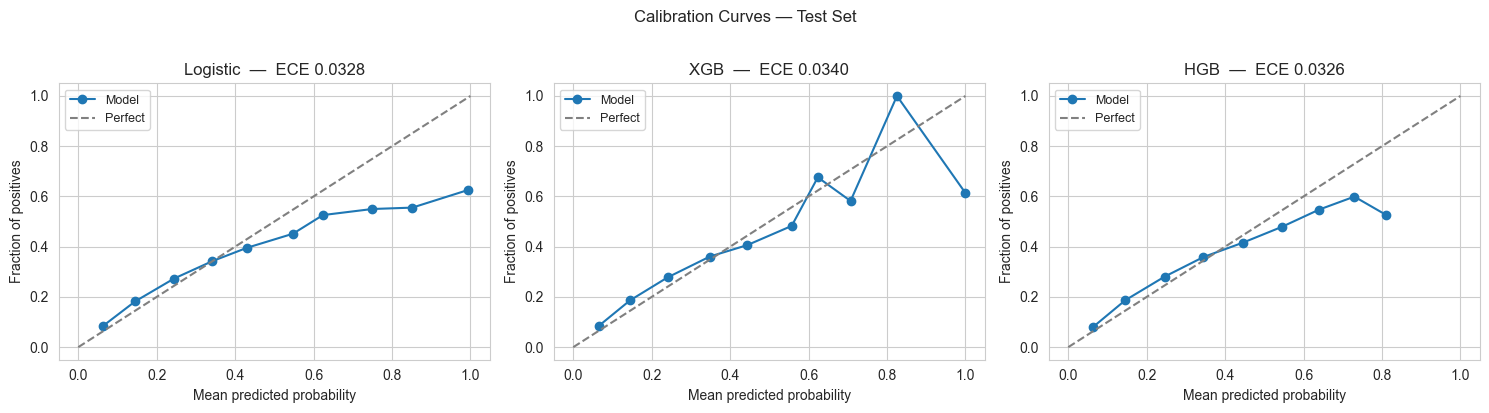

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, d) in zip(axes, trained.items()):
    prob_true, prob_pred = calibration_curve(
        y_test, d['probs_test'], n_bins=10
    )
    ece = compute_ece(y_test.values, d['probs_test'])
    ax.plot(prob_pred, prob_true, marker='o', label='Model')
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect')
    ax.set_title(f"{name}  —  ECE {ece:.4f}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves — Test Set", y=1.02)
plt.tight_layout()
plt.savefig("../visualizations/calibration_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()

**Probability distribution**

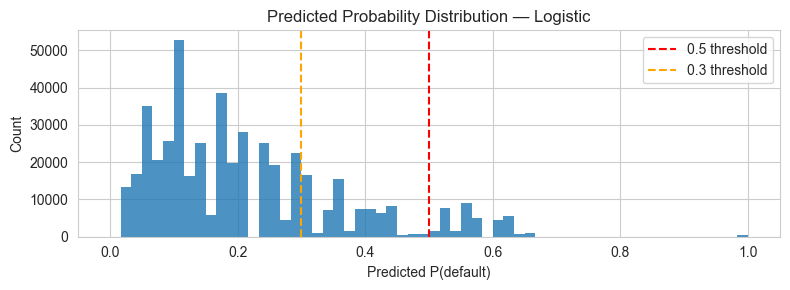

=== PROBABILITY DISTRIBUTION DIAGNOSTICS ===

Sharpness (variance)     : 0.0224
Mean predicted P(default): 0.2151
Actual default rate      : 0.2288
Calibration gap (mean)   : 0.0137

Fraction predicted > 0.5 : 0.0783
Fraction predicted > 0.3 : 0.2307
Fraction predicted > 0.2 : 0.4377

Prediction range distribution:
  0–0.1:  111,402  (23.2%)
  0.1–0.2:  158,317  (33.0%)
  0.2–0.3:   99,331  (20.7%)
  0.3–0.4:   49,041  (10.2%)
  0.4–0.5:   24,095  (5.0%)
  0.5–0.6:   24,975  (5.2%)
  0.6+:   12,565  (2.6%)


In [14]:
probs_arr = np.array(final_probs)

plt.figure(figsize=(8, 3))
plt.hist(probs_arr, bins=60, edgecolor='none', alpha=0.8)
plt.axvline(0.5, color='red',    linestyle='--', label='0.5 threshold')
plt.axvline(0.3, color='orange', linestyle='--', label='0.3 threshold')
plt.title(f"Predicted Probability Distribution — {FINAL_MODEL_NAME}")
plt.xlabel("Predicted P(default)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/prob_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("=== PROBABILITY DISTRIBUTION DIAGNOSTICS ===\n")
print(f"Sharpness (variance)     : {np.var(probs_arr):.4f}")
print(f"Mean predicted P(default): {probs_arr.mean():.4f}")
print(f"Actual default rate      : {y_test.mean():.4f}")
print(f"Calibration gap (mean)   : "
      f"{abs(probs_arr.mean() - y_test.mean()):.4f}")
print(f"\nFraction predicted > 0.5 : {(probs_arr > 0.5).mean():.4f}")
print(f"Fraction predicted > 0.3 : {(probs_arr > 0.3).mean():.4f}")
print(f"Fraction predicted > 0.2 : {(probs_arr > 0.2).mean():.4f}")

print(f"\nPrediction range distribution:")
bins_diag  = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 1.0]
labels_diag = ['0–0.1','0.1–0.2','0.2–0.3',
                '0.3–0.4','0.4–0.5','0.5–0.6','0.6+']
counts = (pd.cut(probs_arr, bins=bins_diag, labels=labels_diag)
            .value_counts()
            .sort_index())
for label, count in counts.items():
    print(f"  {label}: {count:>8,}  ({count/len(probs_arr)*100:.1f}%)")

**Interpretation: Probability Compression**

The model produces low-variance probabilities concentrated in [0.1–0.3].
This results in a low-signal decision environment, where cases are not trivially separable. Such conditions are desirable for studying human–AI interaction, as they increase reliance on probabilistic reasoning and amplify the role of interaction structure in decision-making. 

**Confusion matrices at multiple thresholds**

The DSS presents probabilities to participants — it does NOT
make binary approve/reject decisions. Threshold-based analysis
is included here solely as a diagnostic to:
  
  (a) document class imbalance behavior
  
  (b) show recall-precision tradeoff at different operating points

Primary evaluation metrics are Brier and ECE (probability-based).

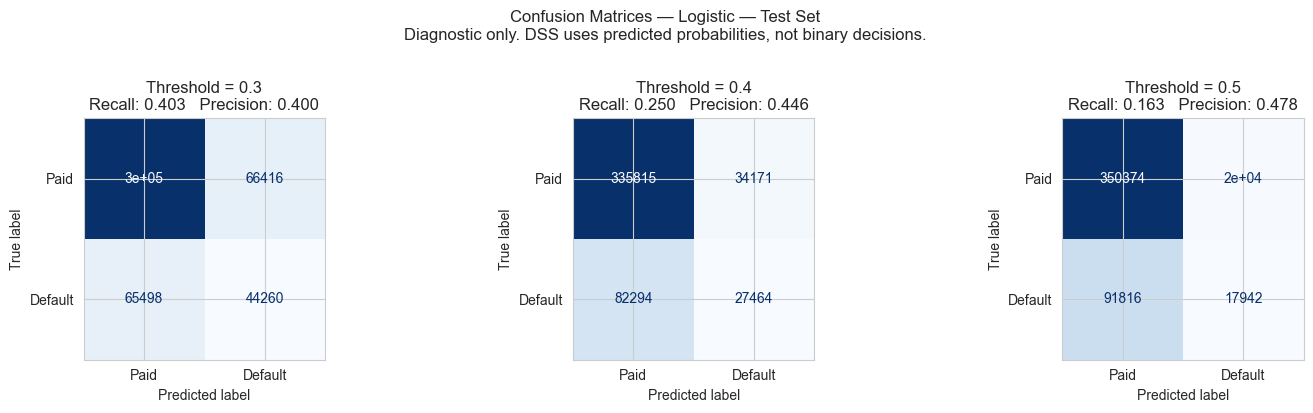

In [15]:
thresholds = [0.3, 0.4, 0.5]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, thresh in zip(axes, thresholds):
    preds = (final_probs >= thresh).astype(int)
    cm    = confusion_matrix(y_test, preds)
    disp  = ConfusionMatrixDisplay(cm, display_labels=['Paid', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    ax.set_title(
        f"Threshold = {thresh}\n"
        f"Recall: {recall:.3f}   Precision: {precision:.3f}"
    )

plt.suptitle(
    f"Confusion Matrices — {FINAL_MODEL_NAME} — Test Set\n"
    "Diagnostic only. DSS uses predicted probabilities, "
    "not binary decisions.",
    y=1.02
)
plt.tight_layout()
plt.savefig("../visualizations/confusion_matrices.png",
            dpi=150, bbox_inches='tight')
plt.show()

**Feature distribution shift**

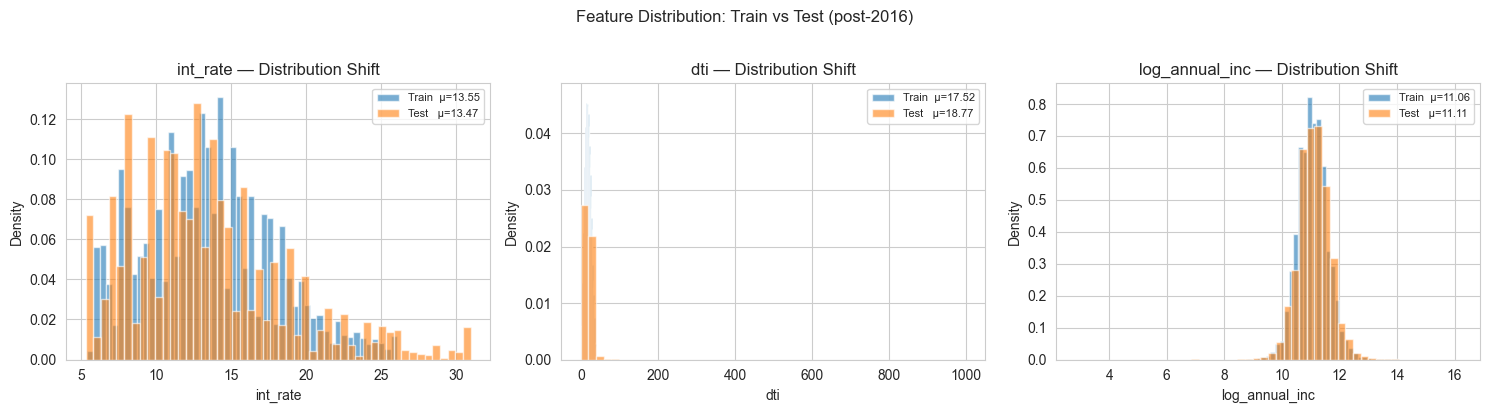

=== FEATURE DISTRIBUTION SHIFT ===

int_rate              train μ=13.548  test μ=13.467  Δ=-0.081
dti                   train μ=17.524  test μ=18.766  Δ=+1.242
log_annual_inc        train μ=11.058  test μ=11.115  Δ=+0.056


In [16]:
shift_features = ['int_rate', 'dti', 'log_annual_inc']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, shift_features):
    ax.hist(train[col].dropna(), bins=50, alpha=0.6, density=True,
            label=f'Train  μ={train[col].mean():.2f}')
    ax.hist(test[col].dropna(),  bins=50, alpha=0.6, density=True,
            label=f'Test   μ={test[col].mean():.2f}')
    ax.set_title(f"{col} — Distribution Shift")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distribution: Train vs Test (post-2016)", y=1.02)
plt.tight_layout()
plt.savefig("../visualizations/feature_shift.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("=== FEATURE DISTRIBUTION SHIFT ===\n")
for col in shift_features:
    delta = test[col].mean() - train[col].mean()
    print(f"{col:20s}  train μ={train[col].mean():.3f}  "
          f"test μ={test[col].mean():.3f}  Δ={delta:+.3f}")

A moderate distribution shift is observed in debt-to-income ratio (Δ ≈ +1.24), indicating mild covariate shift between training and test periods. This further motivates the use of calibrated probabilities rather than threshold-based decisions.

**Export test predictions (final, with features + difficulty)**

In [17]:
test_output = X_test.copy()

# attach identifiers
test_output['case_id'] = case_id_test.values

# attach labels
test_output['y_true'] = y_test.values
test_output['pred_prob'] = final_probs

test_output = test_output.merge(
    test[['case_id', 'difficulty_score', 'difficulty_tier']],
    on='case_id',
    how='left'
)

# reorder
FEATURES_ORDER = list(X_test.columns)

test_output = test_output[[
    'case_id',
    *FEATURES_ORDER,
    'y_true',
    'pred_prob',
    'difficulty_score',
    'difficulty_tier'
]]

# checks
assert not test_output['difficulty_tier'].isna().any(), "Missing difficulty!"

# save
test_output.to_parquet("../../artifacts/test_predictions.parquet", index=False)

print("Saved FULL test_predictions.parquet")

Saved FULL test_predictions.parquet
